In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv('Churn_Modelling.csv')

print("Первые 5 строк данных:")
df.head()

Первые 5 строк данных:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(f"\nРазмер датасета: {df.shape}")

print("\nИнформация о датасете:")
df.info()


Размер датасета: (10000, 14)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
print("Ненужные столбцы удалены.")

df = df.rename(columns={
    'CreditScore': 'CreditScore',
    'Geography': 'Geography',
    'Gender': 'Gender',
    'Age': 'Age',
    'Tenure': 'Tenure',
    'Balance': 'Balance',
    'NumOfProducts': 'NumOfProducts',
    'HasCrCard': 'HasCrCard',
    'IsActiveMember': 'IsActiveMember',
    'EstimatedSalary': 'EstimatedSalary',
    'Exited': 'Exited'
})

df.describe()

Ненужные столбцы удалены.


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


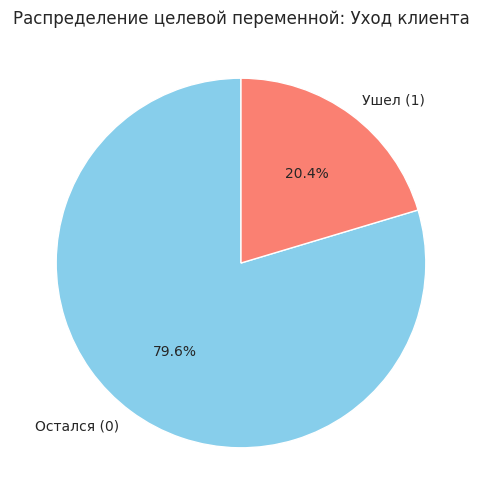

In [6]:
df_clean = df.copy()

churn_counts = df_clean['Exited'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['Остался (0)', 'Ушел (1)'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Распределение целевой переменной: Уход клиента')
plt.show()

Около 80% клиентов остались, а 20% ушли


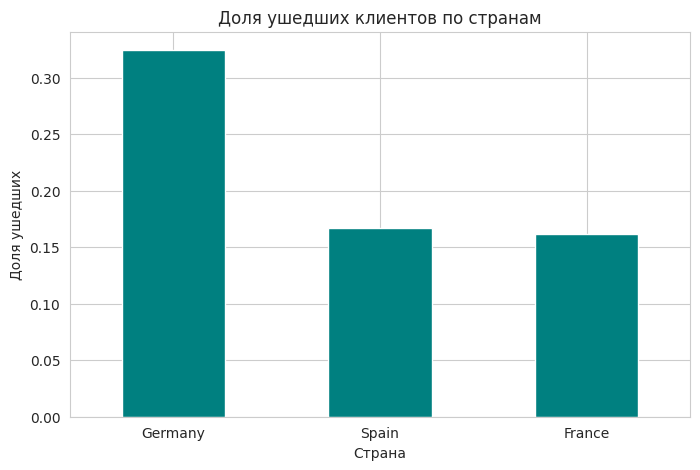

Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64


In [7]:
country_churn = df_clean.groupby('Geography')['Exited'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
country_churn.plot(kind='bar', color='teal')
plt.title('Доля ушедших клиентов по странам')
plt.ylabel('Доля ушедших')
plt.xlabel('Страна')
plt.xticks(rotation=0)
plt.show()

print(country_churn)

Уровень оттока клиентов в Германии значительно выше, чем в Испании и Франции

/tmp/ipykernel_7009/4270671245.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=df_clean, palette='Set2')


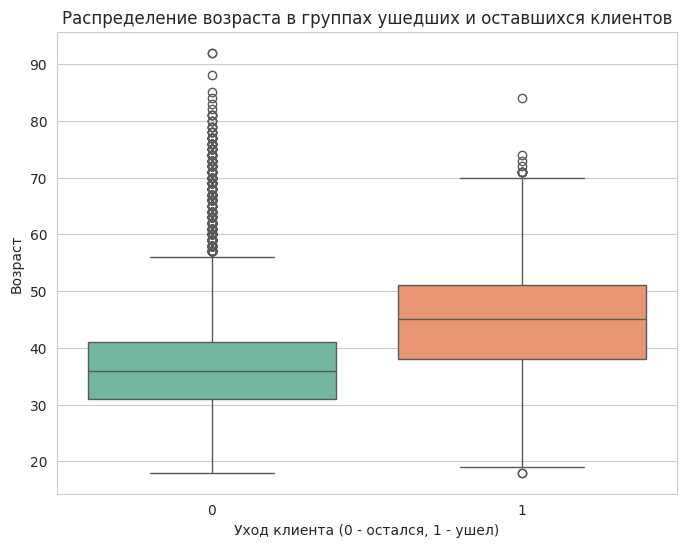

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Exited', y='Age', data=df_clean, palette='Set2')
plt.title('Распределение возраста в группах ушедших и оставшихся клиентов')
plt.xlabel('Уход клиента (0 - остался, 1 - ушел)')
plt.ylabel('Возраст')
plt.show()

У ушедших клиентов возраст в среднем выше

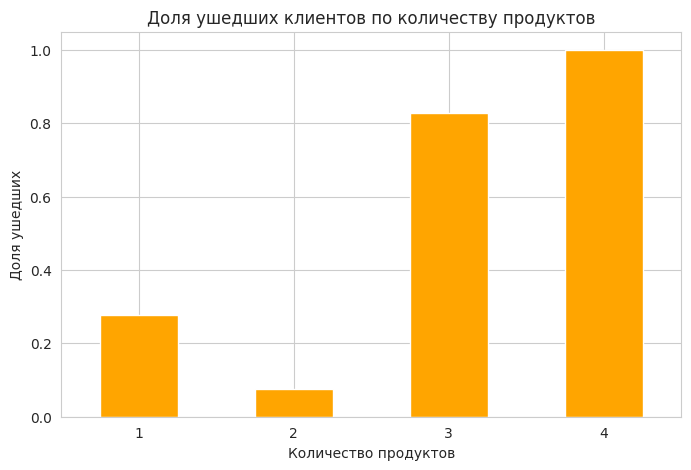

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64


In [9]:
products_churn = df_clean.groupby('NumOfProducts')['Exited'].mean()

plt.figure(figsize=(8,5))
products_churn.plot(kind='bar', color='orange')
plt.title('Доля ушедших клиентов по количеству продуктов')
plt.ylabel('Доля ушедших')
plt.xlabel('Количество продуктов')
plt.xticks(rotation=0)
plt.show()

print(products_churn)

Клиенты с 2 продуктами уходят значительно редко. А у тех, кто использует 3 и 4 продукта, отток довольно высок, что может говорить о недовольстве или о том, что такие продукты сложны в использовании

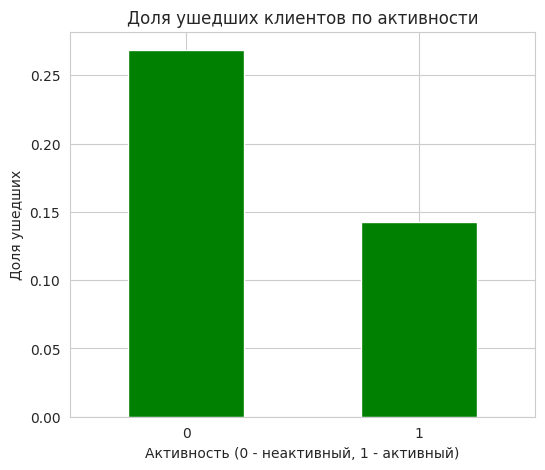

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64


In [10]:
active_churn = df_clean.groupby('IsActiveMember')['Exited'].mean()

plt.figure(figsize=(6,5))
active_churn.plot(kind='bar', color='green')
plt.title('Доля ушедших клиентов по активности')
plt.ylabel('Доля ушедших')
plt.xlabel('Активность (0 - неактивный, 1 - активный)')
plt.xticks(rotation=0)
plt.show()

print(active_churn)

Неактивные клиенты уходят почти в 2 раза чаще



---


**Ключевые выводы:**

- География: Отток клиентов в Германии (32%) существенно выше, чем в Испании и Франции (16%);
- Возраст: Клиенты в возрасте 45-60 лет уходят чаще;
- Продукты: Основная зона риска - клиенты с 1 продуктом;
- Активность: Неактивные клиенты уходят в 2 раза чаще;

**Рекомендации:**

- Программы удержания: Разработать специальные предложения для возрастной группы 45-60 лет, которое по функционалу будет проще и подробнее, чем основное.
- Стратегия продаж: Запустить программу кросс-продаж для клиентов, у которых только 1 продукт банка.
- Работа с регионами: Провести аудит и усилить клиентскую поддержку в Германии.
- Повышение активности: Создать систему бонусов и специальных предложений для вовлечения неактивных клиентов.